In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Save PassengerId from the test set for the final Kaggle submission
test_passenger_ids = test_df['PassengerId']

# Combine training and test sets to ensure consistent feature engineering and preprocessing
train_len = len(train_df)
df_all = pd.concat([train_df, test_df], ignore_index=True)

# ================================================================
# Step 1: Feature Engineering (Extracting hidden information)
# ================================================================
# Fill missing Cabin values with a placeholder 'Z/9999/Z' ('Z' indicates Unknown)
df_all['Cabin'] = df_all['Cabin'].fillna('Z/9999/Z') 

# Extract 'Deck' and 'Side' from the 'Cabin' feature (Format: Deck/Num/Side)
df_all['Cabin_Deck'] = df_all['Cabin'].apply(lambda x: x.split('/')[0])
df_all['Cabin_Side'] = df_all['Cabin'].apply(lambda x: x.split('/')[2])

# Drop raw and irrelevant text columns that do not contribute to distance calculation
df_all.drop(['PassengerId', 'Name', 'Cabin'], axis=1, inplace=True)

# ================================================================
# Step 2: Handling Missing Values
# ================================================================
# Continuous numerical features: Impute with median (robust against outliers like extreme spending)
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in num_cols:
    df_all[col] = df_all[col].fillna(df_all[col].median())

# Categorical features: Impute with the most frequent value (mode)
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for col in cat_cols:
    df_all[col] = df_all[col].fillna(df_all[col].mode()[0])

# ================================================================
# Step 3: Encoding & Scaling (Crucial for KNN Performance)
# ================================================================
# Convert boolean features to integers (0 and 1)
df_all['CryoSleep'] = df_all['CryoSleep'].astype(int)
df_all['VIP'] = df_all['VIP'].astype(int)

# Encode categorical strings into numerical values using Label Encoding
le = LabelEncoder()
for col in ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']:
    df_all[col] = le.fit_transform(df_all[col])

# Feature Scaling: Standardize features to have zero mean and unit variance.
# This is an absolute necessity for distance-based algorithms like KNN.
scaler = StandardScaler()
# Exclude the target variable 'Transported' from scaling
features_to_scale = [col for col in df_all.columns if col != 'Transported']
df_all[features_to_scale] = scaler.fit_transform(df_all[features_to_scale])

# ================================================================
# Step 4: Split data back and prepare feature matrices
# ================================================================
# Split the combined dataframe back into train and test sets
train_clean = df_all.iloc[:train_len].copy()
test_clean = df_all.iloc[train_len:].copy()

# Prepare feature matrix (X) and target vector (y)
X_train = train_clean.drop('Transported', axis=1)
y_train = train_clean['Transported'].astype(int) # Convert True/False to 1/0
X_test = test_clean.drop('Transported', axis=1)

print("Data preprocessing completed successfully!")
print("Training data shape:", X_train.shape)

Data preprocessing completed successfully!
Training data shape: (8693, 12)


/var/folders/2v/vxmhs25x03l375br_qdmwjzr0000gn/T/ipykernel_65871/2087379108.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all[col] = df_all[col].fillna(df_all[col].mode()[0])


Searching for the optimal K value. This might take a few seconds...

✅ Grid Search Completed!
👉 The optimal K value is: 19
👉 The highest cross-validation accuracy is: 0.7826


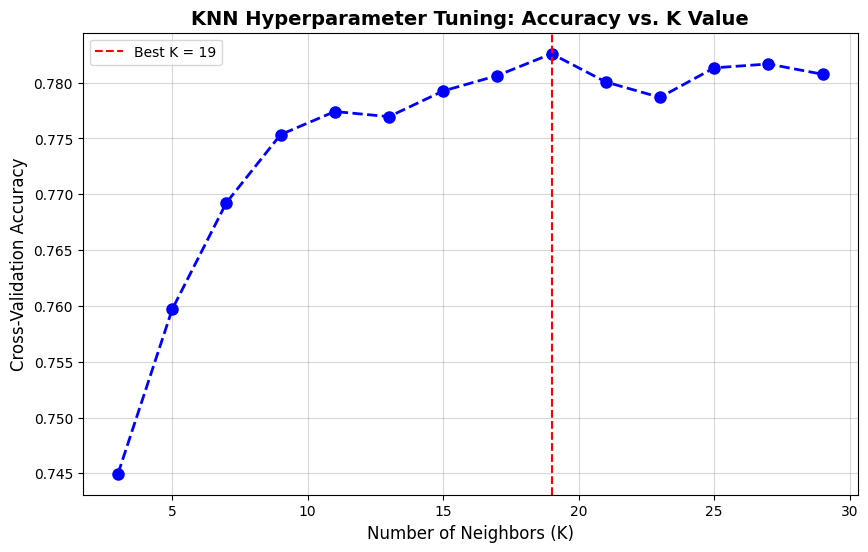

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the range of K values to test (e.g., odd numbers from 3 to 29 to avoid ties)
param_grid = {'n_neighbors': np.arange(3, 30, 2)} 

# 2. Initialize the base KNN model
knn_base = KNeighborsClassifier()

# 3. Configure GridSearchCV
# cv=5 means 5-fold cross-validation, which is crucial for robust evaluation
# n_jobs=-1 uses all available CPU cores to speed up the computation
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Searching for the optimal K value. This might take a few seconds...")

# 4. Fit the model and find the best parameters
grid_search.fit(X_train, y_train)

# ================================================================
# Output the results and generate the visualization
# ================================================================
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"\n✅ Grid Search Completed!")
print(f"👉 The optimal K value is: {best_k}")
print(f"👉 The highest cross-validation accuracy is: {best_score:.4f}")

# Start plotting
plt.figure(figsize=(10, 6))

# Extract the mean cross-validation scores for each K value tested
mean_scores = grid_search.cv_results_['mean_test_score']

# Plot the accuracy line
plt.plot(param_grid['n_neighbors'], mean_scores, color='blue', marker='o', 
         linestyle='dashed', linewidth=2, markersize=8)

# Chart formatting (Excellent addition for your final project report and presentation)
plt.title('KNN Hyperparameter Tuning: Accuracy vs. K Value', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)

# Highlight the best K value with a vertical red dashed line
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.grid(True, alpha=0.5)

# Display the plot
plt.show()

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Load Data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
test_passenger_ids = test_df['PassengerId']

train_len = len(train_df)
df_all = pd.concat([train_df, test_df], ignore_index=True)

# ================================================================
# 🔥 ADVANCED FEATURE ENGINEERING (The key to reaching 0.80+)
# ================================================================

# Feature 1: Extract Group Size from PassengerId (Format: Group_Number)
df_all['Group'] = df_all['PassengerId'].apply(lambda x: x.split('_')[0])
group_counts = df_all['Group'].value_counts().to_dict()
df_all['Group_Size'] = df_all['Group'].map(group_counts)

# Feature 2: Cabin parsing
df_all['Cabin'] = df_all['Cabin'].fillna('Z/9999/Z')
df_all['Cabin_Deck'] = df_all['Cabin'].apply(lambda x: x.split('/')[0])
df_all['Cabin_Side'] = df_all['Cabin'].apply(lambda x: x.split('/')[2])

# Feature 3: Financial Aggregation (Total Spend & Zero Spend Flag)
lux_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# Fill missing financial values with 0 (assuming missing means no spend) before summing
for col in lux_features:
    df_all[col] = df_all[col].fillna(0)

df_all['Total_Spend'] = df_all[lux_features].sum(axis=1)
df_all['No_Spend'] = (df_all['Total_Spend'] == 0).astype(int)

# Drop features that are no longer needed or introduce noise
df_all.drop(['PassengerId', 'Name', 'Cabin', 'Group'], axis=1, inplace=True)

# ================================================================
# Basic Imputation & Encoding
# ================================================================
# Impute Age with median
df_all['Age'] = df_all['Age'].fillna(df_all['Age'].median())

# Impute Categorical with mode
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for col in cat_cols:
    df_all[col] = df_all[col].fillna(df_all[col].mode()[0])

# Convert Booleans
df_all['CryoSleep'] = df_all['CryoSleep'].astype(int)
df_all['VIP'] = df_all['VIP'].astype(int)

# Label Encoding
le = LabelEncoder()
for col in ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']:
    df_all[col] = le.fit_transform(df_all[col])

# ================================================================
# Scaling
# ================================================================
scaler = StandardScaler()
features_to_scale = [col for col in df_all.columns if col != 'Transported']
df_all[features_to_scale] = scaler.fit_transform(df_all[features_to_scale])

# Split back to train/test
train_clean = df_all.iloc[:train_len].copy()
test_clean = df_all.iloc[train_len:].copy()

X_train = train_clean.drop('Transported', axis=1)
y_train = train_clean['Transported'].astype(int)
X_test = test_clean.drop('Transported', axis=1)

# ================================================================
# 🔥 ADVANCED GRID SEARCH (Tuning multiple dimensions)
# ================================================================
# 'weights': uniform vs distance-based voting
# 'p': 1 is Manhattan Distance, 2 is Euclidean Distance
param_grid = {
    'n_neighbors': np.arange(15, 35, 2), # Focused range based on typical best performance
    'weights': ['uniform', 'distance'],
    'p': [1, 2] 
}

knn_base = KNeighborsClassifier()
# n_jobs=-1 is safe now if you fixed the environment variable, otherwise use n_jobs=1
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Running advanced Grid Search... Please wait.")
grid_search.fit(X_train, y_train)

print("\n✅ Optimization Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Highest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# ================================================================
# Generate Final Submission
# ================================================================
best_knn = grid_search.best_estimator_
final_predictions = best_knn.predict(X_test).astype(bool)

submission_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions
})

submission_df.to_csv('submission_knn_optimized.csv', index=False)
print("\nFile 'submission_knn_optimized.csv' is ready for Kaggle!")

Running advanced Grid Search... Please wait.

✅ Optimization Complete!
Best Parameters: {'n_neighbors': np.int64(31), 'p': 1, 'weights': 'uniform'}
Highest Cross-Validation Accuracy: 0.7859

File 'submission_knn_optimized.csv' is ready for Kaggle!


In [4]:
# ================================================================
# Final Step: Prediction and Kaggle Submission
# ================================================================

# 1. Automatically extract the best model found by GridSearchCV
best_knn = grid_search.best_estimator_

print("Generating predictions on the test dataset...")

# 2. Predict the 'Transported' status for the test set
# The model outputs 1 (Transported) or 0 (Not Transported)
test_predictions = best_knn.predict(X_test)

# 3. Convert numerical predictions back to boolean (True/False)
# The Spaceship Titanic Kaggle competition STRICTLY requires True/False values
final_predictions = test_predictions.astype(bool)

# 4. Construct the submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': final_predictions
})

# 5. Export to CSV format
# index=False ensures we don't save the row numbers, which would cause a Kaggle scoring error
submission_file_name = 'submission_knn.csv'
submission_df.to_csv(submission_file_name, index=False)

print(f"\n✅ Success! Predictions saved to '{submission_file_name}'.")
print("\nPreview of your submission file:")
print(submission_df.head())

Generating predictions on the test dataset...

✅ Success! Predictions saved to 'submission_knn.csv'.

Preview of your submission file:
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
